In [1]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
RESULT_FILEPATH = '/Users/egyptdj/github/bruit-classification/results/results-231204/'
FIG_SAVEPATH = '/Users/egyptdj/'
CAROTID_THRESHOLD = 0.5
BRUIT_THRESHOLD = 0.5
PRED_THRESHOLD = 3

In [3]:
sns.set_theme(context='talk', style='white', font='helvetica', font_scale=1.0)

In [4]:
results_files = os.listdir(RESULT_FILEPATH)
results_df = [pd.read_csv(os.path.join(RESULT_FILEPATH, f)) for f in results_files]

In [5]:
def get_pred(df):
    results_array = [np.array(ast.literal_eval(row)) for row in df['predictions']]
    carotid_array = [arr[:,0] for arr in results_array]
    bruit_array = [arr[:,1] for arr in results_array]
    labels = df['normal'].replace({0: 'Stenosis', 1: 'Control'}).to_list()
    
    carotid_pred = [(arr>CAROTID_THRESHOLD).mean() for arr in carotid_array]
    bruit_pred = [((barr>BRUIT_THRESHOLD)*(carr>CAROTID_THRESHOLD)).sum() for barr, carr in zip(bruit_array, carotid_array)]
    correct = [bool(label)!=(bpred>PRED_THRESHOLD) for label, bpred in zip(labels, bruit_pred)]
    
    return carotid_pred, bruit_pred, labels, correct
    

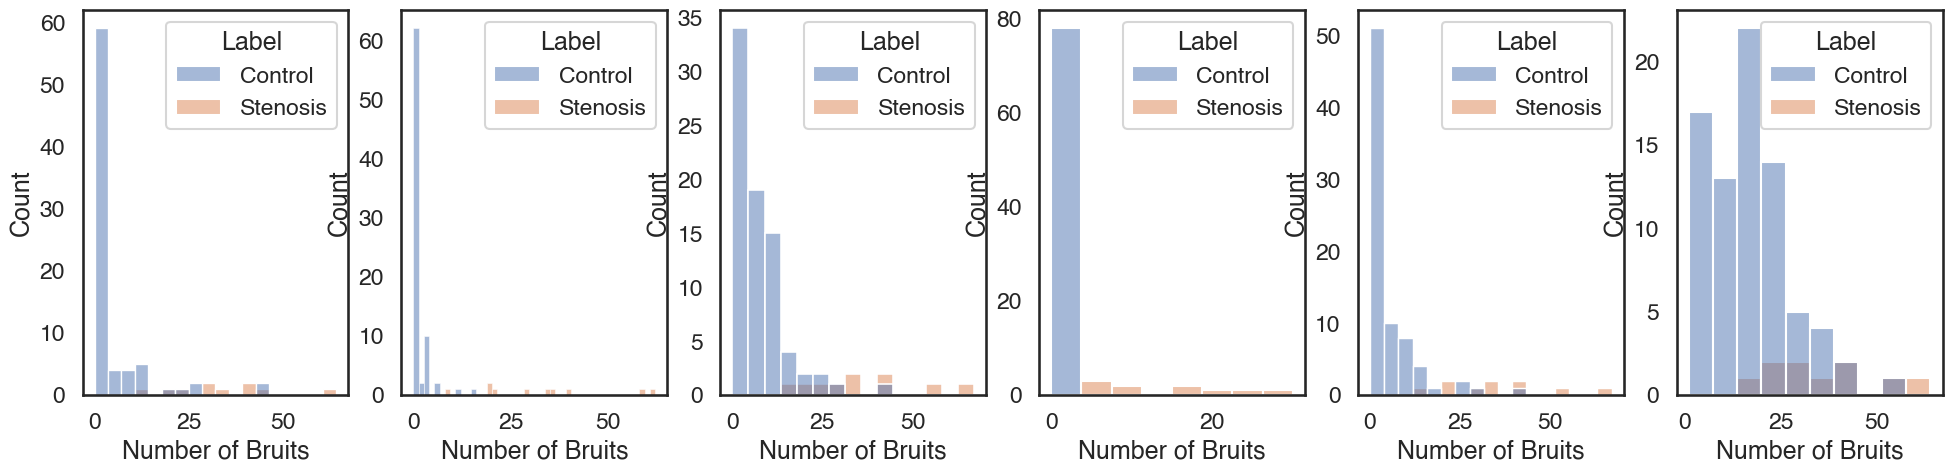

In [6]:
fig, ax = plt.subplots(figsize=(24, 5), ncols=len(results_df))
for i, (df, filename) in enumerate(zip(results_df, results_files)):
    cp, bp, label, correct = get_pred(df)
    histdf = pd.DataFrame.from_dict({'Number of Bruits': bp, 'Label': label})
    sns.histplot(data=histdf, x='Number of Bruits', hue='Label', ax=ax[i])

4번째 결과 가장 좋으므로 results_files[3] 을 기준으로 분석

In [7]:
df = results_df[3]
print(results_files[3])

231204-model_noiseasnormal_nomult_step2mlp64_twostep_length15600.csv


In [8]:
cp, bp, label, correct = get_pred(df)

In [9]:
bp_stenosis = []
bp_control = []
for l, p in zip(label, bp):
    if l=='Stenosis':
        bp_stenosis.append(p)
    else:
        bp_control.append(p)
print(min(bp_stenosis), max(bp_stenosis))
print(min(bp_control), max(bp_control))

5 30
0 2


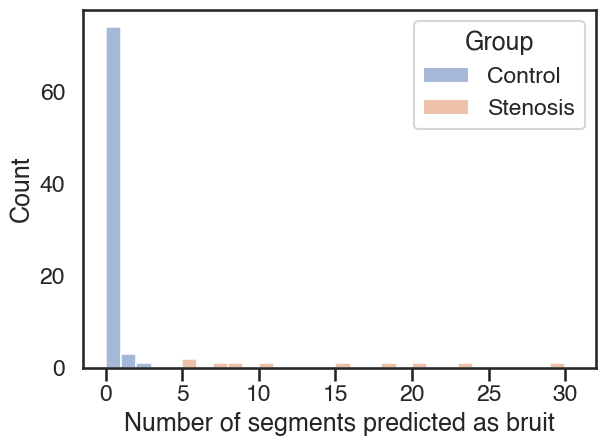

In [14]:
histdf = pd.DataFrame.from_dict({'Bruits': bp, 'Group': label})
# ax = sns.histplot(data=histdf, x='Bruits', hue='Group')
ax = sns.histplot(data=histdf, x='Bruits', hue='Group', bins=range(0, max(bp)+1, 1))
plt.xticks(range(0, max(bp)+4, 4))
# plt.xticks(range(0, max(bp)+1))
ax.set(xlabel='Number of segments predicted as bruit')
ax.xaxis.tick_bottom()
plt.xticks(range(0, 31, 5))
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVEPATH, 'bruit_pred.svg'), format='svg')

# for i, p in enumerate(ax.patches):
#     print(p)
#     ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha='center', va='baseline', fontsize=10)

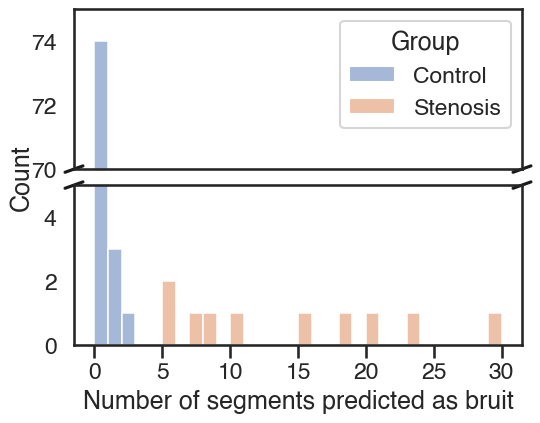

In [11]:
# let's create a figure for our two plots to live in
# we need a lower part (anything below the cutoff), which will be ax2
# and an upper part (anything above the cutoff) which will be ax1
# because we have only two plots above each other, we set ncols=1 and nrows=2
# also, they should share an x axis, which is why we set sharex=True
f, (ax1, ax2) = plt.subplots(ncols=1, nrows=2,
                             sharex=True)

# we want the "Test" to appear on the x axis as individual parameters
# "Latency in ms" should be what is shown on the y axis as a value
# hue should be the "Experiment Setup"
# this will result three ticks on the x axis with X1...X3 and each with three bars for T1...T3
# (you could turn this around if you need to, depending on what kind of data you want to show)
ax1 = sns.histplot(data=histdf, x="Bruits", hue='Group', bins=range(0, max(bp)+1, 1), ax=ax1)

# we basically do the same thing again for the second plot
ax2 = sns.histplot(data=histdf, x="Bruits", hue='Group', bins=range(0, max(bp)+1, 1), ax=ax2)

# here is the fun part: setting the limits for the individual y axis
# the upper part (ax1) should show only values from 250 to 400
# the lower part (ax2) should only show 0 to 150
# you can define your own limits, but the range (150) should be the same so scale is the same across both plots
# it could be possible to use a different range and then adjust plot height but who knows how that works
ax1.set_ylim(70, 75)
ax2.set_ylim(0, 5)

# the upper part does not need its own x axis as it shares one with the lower part
ax1.get_xaxis().set_visible(False)

# by default, each part will get its own "Latency in ms" label, but we want to set a common for the whole figure
# first, remove the y label for both subplots
ax1.set_ylabel("")
ax2.set_ylabel("")
# then, set a new label on the plot (basically just a piece of text) and move it to where it makes sense (requires trial and error)
f.text(0.05, 0.5, "Count", va="center", rotation="vertical")

# by default, seaborn also gives each subplot its own legend, which makes no sense at all
# soe remove both default legends first
# ax1.get_legend().remove()
ax2.get_legend().remove()
# then create a new legend and put it to the side of the figure (also requires trial and error)
# ax2.legend(loc=(1.025, 0.5), title="Group")

# let's put some ticks on the top of the upper part and bottom of the lower part for style
ax1.xaxis.tick_top()
ax2.xaxis.tick_bottom()

ax2.set(xlabel='Number of segments predicted as bruit')

d = .02  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)

ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# finally, adjust everything a bit to make it prettier (this just moves everything, best to try and iterate)
f.subplots_adjust(left=0.15, right=0.85, bottom=0.15, top=0.85, hspace=0.1)
plt.xticks(range(0, 31, 5))

# plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(FIG_SAVEPATH, 'bruit_pred_1.svg'), format='svg')


0.9142965579819258 1.0 0.7021276595744681 0.06743558681706256 0.936608398633715 0.09936782743086381


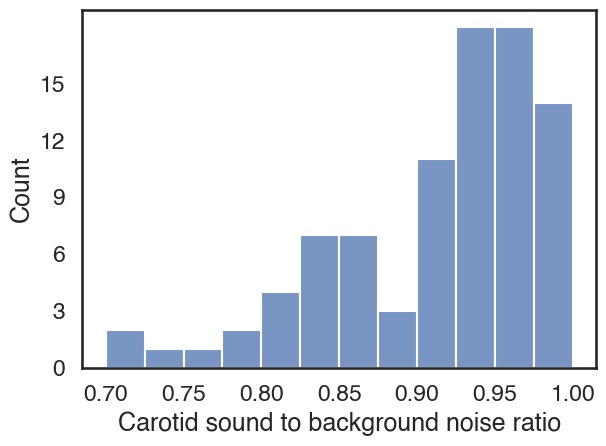

In [12]:
print(np.mean(cp), max(cp), min(cp), np.std(cp), np.median(cp), np.subtract(*np.percentile(cp, [75, 25])))
sns.histplot(x=cp, bins=np.arange(0.70, 1.00+1e-9, 0.025)).set(xlabel='Carotid sound to background noise ratio')
plt.yticks(np.arange(0, 18, 3))
plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVEPATH, 'carotid_ratio.svg'), format='svg')

In [13]:
TEST_METRIC_FILE = 'models/model_noiseasnormal_nomult_step2mlp64_twostep_length15600/test_metrics.csv'
metric_df = pd.read_csv(TEST_METRIC_FILE)
metric_df.columns = ['Model', 'Loss', 'Accuracy', 'Precision', 'Recall', 'ROC AUC']
metric_df = metric_df.replace({'step1': 'Carotid sound recognizer', 'step2': 'Bruit classifier'})
metric_df[['Accuracy', 'Precision', 'Recall']] = metric_df[['Accuracy', 'Precision', 'Recall']].apply(lambda x: x*100)
metric_df

,Model,Loss,Accuracy,Precision,Recall,ROC AUC
0,Carotid sound recognizer,0.2469,91.52,77.04,82.57,0.9887
1,Bruit classifier,0.3636,81.69,87.76,49.40,0.6891
